In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
%matplotlib inline

random.seed(13337)
np.random.seed(13337)


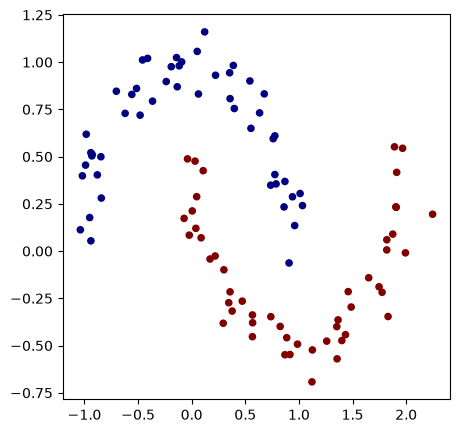

In [6]:
from sklearn.datasets import make_moons
X,y=make_moons(n_samples=100,noise=0.1)
X=torch.tensor(X).float()
y=torch.tensor(y).float()

y=y*2-1

plt.figure(figsize=(5,5))
plt.scatter(X[:,0],X[:,1],c=y,s=20,cmap='jet')

In [7]:
from torch.utils.data import TensorDataset,DataLoader
dataset =TensorDataset(X,y)

dataloader = DataLoader(dataset,batch_size=32,shuffle=True)

class mlp(nn.Module):
  def __init__(self, *args, **kwargs) -> None:
    super().__init__(*args, **kwargs)
    self.fc1=nn.Linear(2,16) # 第一隐藏层
    self.fc2=nn.Linear(16,16) # 第二隐藏层
    self.fc3=nn.Linear(16,1) # 输出层

  # forward 函数是调用 model(x) 时执行的函数
  def forward(self,x):
    x=F.relu(self.fc1(x)) # F.relu 对我们的层输出应用 ReLU 激活函数
    x=F.relu(self.fc2(x))
    output=self.fc3(x)
    return output


Epoch 0: loss=2.412, accuracy=66.0%
Epoch 10: loss=0.803, accuracy=90.0%
Epoch 20: loss=0.915, accuracy=91.0%
Epoch 30: loss=0.735, accuracy=93.0%
Epoch 40: loss=0.479, accuracy=95.0%
Epoch 50: loss=0.295, accuracy=96.0%
Epoch 60: loss=0.113, accuracy=100.0%
Epoch 70: loss=0.073, accuracy=100.0%
Epoch 80: loss=0.196, accuracy=100.0%
Epoch 90: loss=0.021, accuracy=100.0%


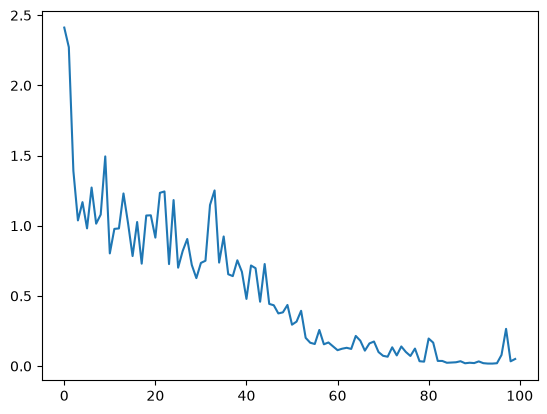

In [8]:
model=mlp()
epochs = 100
optimizer = torch.optim.SGD(model.parameters(), lr=1.0)        # 初始学习率 1.0
scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1.0, end_factor=0.1               # 1.0 → 0.1
)

loss_epoch_log = []

for epoch in range(epochs):
    loss_epoch = 0
    correct = 0
    total = 0

    for batch_X, batch_y in dataloader:
        scores = model(batch_X)

        # ---- 改1：Hinge Loss，和手撕版一致 ----
        loss = (1 - batch_y.unsqueeze(1) * scores).clamp(min=0).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_epoch += loss.item()
        correct += ((scores.data > 0) == (batch_y.unsqueeze(1) > 0)).sum().item()
        total += len(batch_y)
     
    loss_epoch_log.append(loss_epoch)
    scheduler.step()                                          # 每个 epoch 衰减
       
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss={loss_epoch:.3f}, accuracy={correct/total*100:.1f}%")
    
plt.plot(loss_epoch_log)


C:\Users\Thinkbook\AppData\Local\Temp\ipykernel_8796\2006914296.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
C:\Users\Thinkbook\AppData\Local\Temp\ipykernel_8796\2006914296.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, h))


(-1.692277431488037, 2.057722568511963)

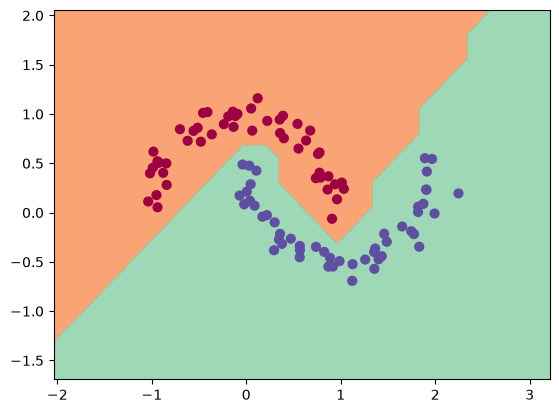

In [9]:
# 决策边界可视化
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]

inputs = torch.tensor(Xmesh).float()

with torch.no_grad():                              # 推理时不记录梯度
    scores = model(inputs)

Z = (scores > 0).numpy()                           # ← 直接布尔判断，形状 (N, 1)
Z = Z.reshape(xx.shape)                            # ← 重塑成网格形状

plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
